# Detecção de objetos usando mapas de ativação — Experimentos

Este notebook segue o roteiro proposto para detecção de objetos utilizando mapas de ativação de redes neurais convolucionais. O objetivo é identificar a posição de um cachorro em imagens onde ele ocupa uma pequena parte da cena, utilizando diferentes variantes da ResNet.

## 1. Coleta das imagens

Faça o download de 10 imagens da internet contendo cachorros que ocupam uma pequena parte da imagem. Salve-as em uma pasta, por exemplo, `imagens_cachorros/`.

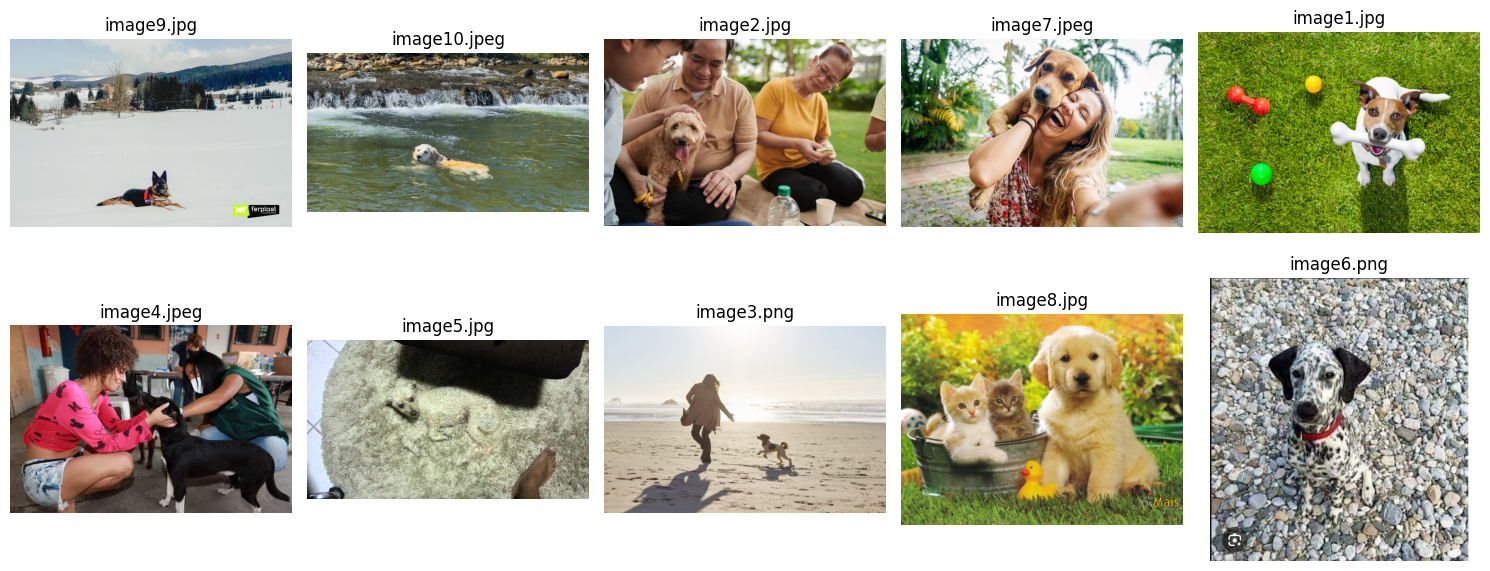

In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Caminho para as imagens
caminho_imagens = 'images_dogs/'
nomes_imagens = [f for f in os.listdir(caminho_imagens) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Exemplo de visualização das imagens
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i, nome in enumerate(nomes_imagens[:10]):
    img = Image.open(os.path.join(caminho_imagens, nome))
    axs[i//5, i%5].imshow(img)
    axs[i//5, i%5].set_title(nome)
    axs[i//5, i%5].axis('off')
plt.tight_layout()
plt.show()

## 2. Obtenção das ativações da última camada da ResNet18 treinada no ImageNet

Utilizaremos a ResNet18 pré-treinada no ImageNet para extrair o mapa de ativações antes do global pooling.

In [3]:
import torch
from torch import nn
from torchvision import models
import torchvision.transforms.v2 as transf

class Transforms:
    def __init__(self):
        self.transforms = transf.Compose([
            transf.PILToTensor(),
            transf.Resize(size=(2*224,2*224), antialias=True),
            transf.ToDtype(torch.float32),
            transf.Normalize(mean=(122.7, 114.6, 100.9), std=(59.2, 58.4, 59.0))
        ])
    def __call__(self, img):
        return self.transforms(img)

class ModelMapResNet18(nn.Module):
    """Extrai as ativações antes do global pooling de uma resnet18."""
    def __init__(self):
        super().__init__()
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.eval()
        model.avgpool = nn.Identity()
        model.fc = nn.Identity()
        self.model = model
    def forward(self, x):
        x = self.model(x)
        x = x.reshape(512, 14, 14)
        return x.mean(dim=0)

## 3. Detecção da posição do valor máximo da ativação

Para cada imagem, vamos identificar a posição do valor máximo no mapa de ativação.

In [4]:
def detectar_maximo_ativacao(mapa_ativacao):
    max_idx = torch.argmax(mapa_ativacao)
    max_pos = (max_idx // mapa_ativacao.shape[1], max_idx % mapa_ativacao.shape[1])
    return max_pos

## 4. Cálculo da posição respectiva na imagem original

Como a imagem é redimensionada para 448x448 e o mapa de ativação é 14x14, é necessário calcular a posição correspondente na imagem original.

In [5]:
def posicao_na_imagem_original(pos_ativacao, tamanho_original, tamanho_redimensionado=(448,448), tamanho_mapa=(14,14)):
    fator_x = tamanho_original[0] / tamanho_redimensionado[0]
    fator_y = tamanho_original[1] / tamanho_redimensionado[1]
    x = int(pos_ativacao[1] * (tamanho_redimensionado[0] / tamanho_mapa[0]) * fator_x)
    y = int(pos_ativacao[0] * (tamanho_redimensionado[1] / tamanho_mapa[1]) * fator_y)
    return (x, y)

## 5. Repetição com outros modelos

Repita o procedimento para a ResNet18 refinada no Oxford Pets e para a ResNet50 treinada no ImageNet. Basta adaptar a classe do modelo conforme necessário.

In [6]:
class ModelMapResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.eval()
        model.avgpool = nn.Identity()
        model.fc = nn.Identity()
        self.model = model
    def forward(self, x):
        x = self.model(x)
        x = x.reshape(2048, 14, 14)
        return x.mean(dim=0)

# Para a ResNet18 refinada, carregue os pesos customizados se disponíveis

## 6. Avaliação qualitativa

Visualize os resultados marcando a posição detectada sobre a imagem original e discuta a acurácia qualitativamente.

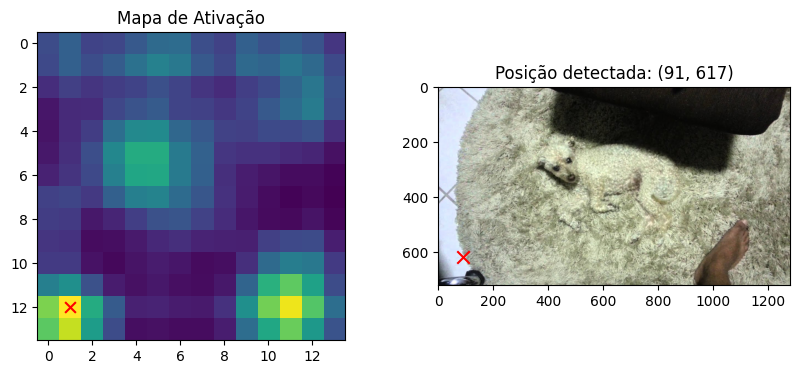

In [17]:
# Exemplo de visualização para uma imagem
def visualizar_resultado(img_path, modelo, transform):
    img = Image.open(img_path)
    img_t = transform(img)
    with torch.no_grad():
        mapa = modelo(img_t.unsqueeze(0))
    pos_max = detectar_maximo_ativacao(mapa)
    pos_img = posicao_na_imagem_original(pos_max, img.size)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(mapa.cpu(), cmap='viridis')
    ax1.set_title('Mapa de Ativação')
    ax1.scatter([pos_max[1]], [pos_max[0]], color='red', s=60, marker='x')
    ax2.imshow(img)
    ax2.scatter([pos_img[0]], [pos_img[1]], color='red', s=80, marker='x')
    ax2.set_title(f'Posição detectada: {pos_img}')
    plt.show()

# Exemplo de uso:
visualizar_resultado(os.path.join(caminho_imagens, nomes_imagens[6]), ModelMapResNet18(), Transforms())

---

Preencha as células com os resultados e discussões qualitativas após rodar os experimentos.